# How have player demographics changed over the history of the league?

Here you will find my slightly more unedited and data-forward look at the data for this post. This won't be anything crazy, but perhaps a little more technical, a little more raw data and raw code. My overall design philosophy for this website is to be design and story forward on the front-end, but with more technical detail easily available for the folks who are so inclined. With that, let's look a bit more closely at the raw data.

## Nationality: From pure Canada to North American Mix

In [1]:
# ----------------------------------------------------------------------
#
# LIBRARIES
#
# ----------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl

# Make sure you're not overwriting later
mpl.rcParams['font.family'] = 'Charter'
print("Using font:", mpl.rcParams['font.family'])  # should say ['Charter']


# Hardcoded project root (adjust if you move the repo)
PROJECT_ROOT = "/Users/dwiwad/dev/hockey_site"

def save_figure(filename):
    output_dir = os.path.join(
        PROJECT_ROOT,
        "static/images/deep-dives/nhl-player-demographics"
    )
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)
    # Full path to save the image
    output_path = os.path.join(output_dir, filename)
    # Save the figure
    plt.savefig(output_path, dpi=300, transparent=True)
    print(f"✅ Saved: {output_path}")

Using font: ['Charter']


In [2]:
# ----------------------------------------------------------------------
#
# READ IN THE DATA
#
# ----------------------------------------------------------------------

roster = pd.read_csv("~/dev/hockey_site/data/nhl-player-demographics/rosters.csv")

# ----------------------------------------------------------------------
#
# ROSTER COUNTS
#
# ----------------------------------------------------------------------

print('Total number of NHL rostered players from 1917 to 2025:', len(roster))
print('Total roster years:', roster['season'].nunique())
print('Total unique rostered players from 1917 to 2025:', roster['id'].nunique())

Total number of NHL rostered players from 1917 to 2025: 55567
Total roster years: 107
Total unique rostered players from 1917 to 2025: 8595


In [5]:
# ----------------------------------------------------------------------
#
# NATIONALITY PROPORTIONS IN THE 2024-2025 AND OVERALL PLOT
#
# ----------------------------------------------------------------------

# Get the simple counts of country by season
country_year_df = roster.groupby(['season', 'birth_country']).size().reset_index(name='count')

# Add in total players per season
country_year_df['total_players'] = country_year_df.groupby('season')['count'].transform('sum')

# Add in proportions
country_year_df['country_prop'] = (country_year_df['count'] / country_year_df['total_players'])

# Split season into a nice labelled variable
def split_and_hyphenate(number):
    s_number = str(number)
    # Example: Split into first 3 and remaining digits
    part1 = s_number[:4]
    part2 = s_number[4:]
    return f"{part1}-{part2}"

# Apply the function to create a new column
country_year_df['season_label'] = country_year_df['season'].apply(split_and_hyphenate)

# Clean up the countries into groupings
def map_country_group(country):
    if country == 'CAN':
        return 'Canada'
    elif country == 'USA':
        return 'USA'
    elif country in ['SWE', 'FIN', 'NOR', 'DNK']:
        return 'Scandinavia'
    elif country in ['CZE', 'SVK']:
        return 'Central Europe'
    elif country in ['RUS', 'BLR', 'UKR', 'KAZ']:
        return 'Former USSR'
    elif country in ['DEU', 'AUT', 'SUI']:  # Germany, Austria, Switzerland
        return 'Western Europe'
    elif country in ['FRA', 'GBR', 'IRL', 'NLD', 'BEL']:
        return 'Other Europe'
    else:
        return 'Other'

# Apply dataframe dataframe
country_year_df['country_group'] = country_year_df['birth_country'].apply(map_country_group)

# ----------------------------------------------------------------------
# AGGREGATION FOR PLOTTING
# ----------------------------------------------------------------------

# Get the max season
latest_season = country_year_df['season'].max()

# Get the latest group totals
latest_group_totals = (
    country_year_df.query("season == @latest_season")
    .groupby('country_group', as_index=False)['country_prop']
    .sum()
)

latest_order = (
    latest_group_totals
    .sort_values('country_prop', ascending=False)['country_group']
    .tolist()
)

top_groups = latest_group_totals.nlargest(5, 'country_prop')['country_group'].tolist()

# aggregate to group-by-season before plotting 
plot_df = (
    country_year_df[country_year_df['country_group'].isin(top_groups)]
    .groupby(['season', 'country_group'], as_index=False)['country_prop']
    .sum()
)

# Re-add the season label
plot_df['season_label'] = plot_df['season'].apply(split_and_hyphenate)

# Convert to categorical to enforce order
plot_df['country_group'] = pd.Categorical(plot_df['country_group'], categories=top_groups, ordered=True)


### Plot the country trends

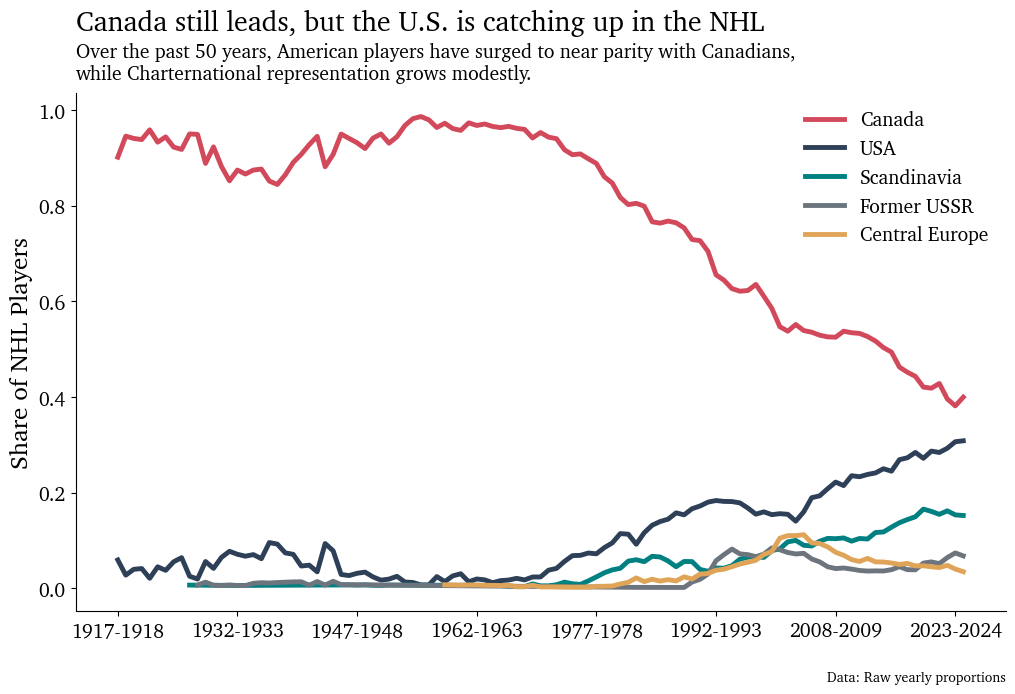

In [7]:
# ----------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=plot_df,
    x="season_label",
    y="country_prop",
    hue="country_group",
    palette={
        'Canada': '#D1495B',
        'USA': '#2E4057',
        'Scandinavia': '#008080',
        'Central Europe': '#E0A458',
        'Former USSR': '#6C757D'
    },
    linewidth=3.5,
    ax=ax,
    errorbar=None  
)

# Set a clean aesthetic style
mpl.rcParams['font.family'] = 'Charter'
sns.despine()
ax.grid(False)

# X-tick labels
# Get unique season labels every 15 steps
tick_labels = plot_df['season_label'].unique()[::15]

# Set ticks and labels using actual string values
ax.set_xticks(tick_labels)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Share of NHL Players", fontsize=18)

# Calculate left margin in figure coords
left_x = ax.get_position().x0

# Reserve more space at the top for the titles
plt.subplots_adjust(top=0.85)  # moves the plot down, freeing top 15% of figure height

# Title (main)
fig.suptitle(
    "Canada still leads, but the U.S. is catching up in the NHL",
    fontsize=20,
    weight='bold',
    x=left_x,
    ha='left',
    y=.97  # Top of reserved space
)

# Subtitle
fig.text(
    left_x,
    0.87,  # Slightly below the main title
    "Over the past 50 years, American players have surged to near parity with Canadians,\n"
    "while Charternational representation grows modestly.",
    fontsize=14,
    ha='left'
)

fig.text(
    0.9,
    0.01,
    "Data: Raw yearly proportions", 
    fontsize=10, 
    style='italic', 
    ha='right'
)

# Legend
ax.legend(title="", frameon=False, loc='upper right', fontsize=14)

plt.show()